In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore", "use_inf_as_na")

In [3]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# Matplotlib `.plot.scatter()`

## Simple scatter plot

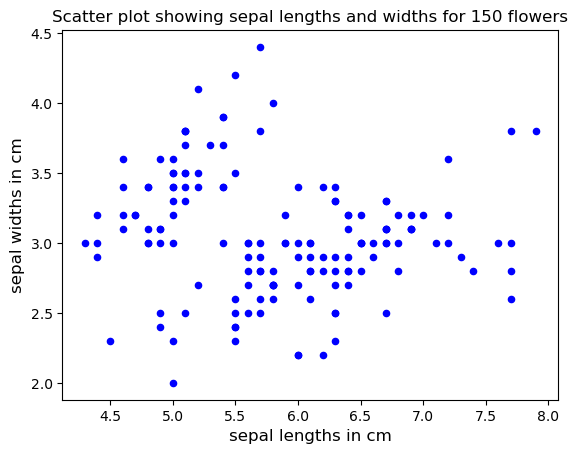

In [4]:
ax = iris.plot.scatter(x="sepal_length", y="sepal_width", color="Blue")
ax.set_xlabel("sepal lengths in cm", fontsize=12)
ax.set_ylabel("sepal widths in cm", fontsize=12)
ax.set_title("Scatter plot showing sepal lengths and widths for 150 flowers")
plt.show()

## Advanced scatterplot with colour control

- grouped on the *species* feature

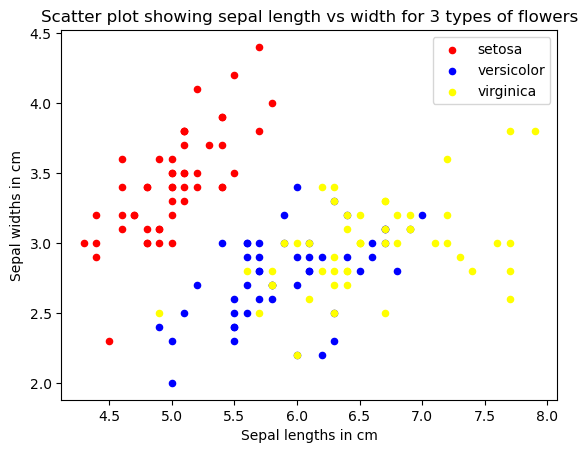

In [5]:
fig, ax = plt.subplots()
colours = {"setosa": "Red",
           "versicolor": "Blue",
           "virginica": "Yellow",
          }
for species, data in iris.groupby("species"):
    data.plot(kind="scatter", x="sepal_length", y="sepal_width", label=species, color=colours[species], ax=ax)
ax.set_xlabel("Sepal lengths in cm")
ax.set_ylabel("Sepal widths in cm")
fig.suptitle("")
ax.set_title("Scatter plot showing sepal length vs width for 3 types of flowers")
plt.show()

***

- special markers

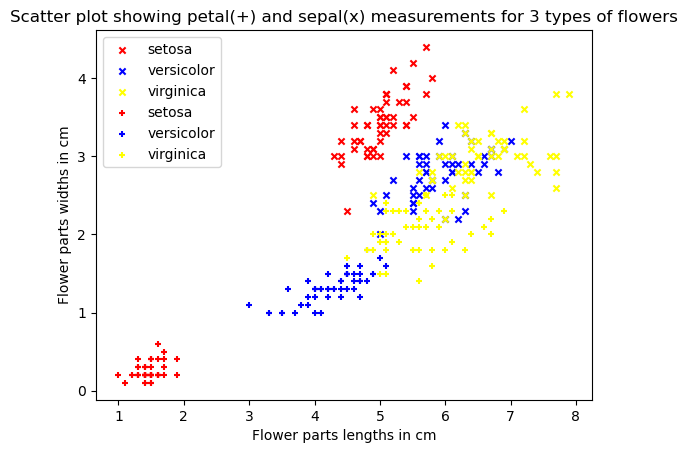

In [6]:
fig, ax = plt.subplots()
colours = {"setosa": "Red",
           "versicolor": "Blue",
           "virginica": "Yellow",
          }
for species, data in iris.groupby("species"):
    data.plot(kind="scatter", x="sepal_length", y="sepal_width", label=species, color=colours[species], marker="x", ax=ax)
for species, data in iris.groupby("species"):
    data.plot(kind="scatter", x="petal_length", y="petal_width", label=species, color=colours[species], marker="+", ax=ax) 
ax.set_xlabel("Flower parts lengths in cm")
ax.set_ylabel("Flower parts widths in cm")
fig.suptitle("")
ax.set_title("Scatter plot showing petal(+) and sepal(x) measurements for 3 types of flowers")
plt.show()

# Seaborn

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

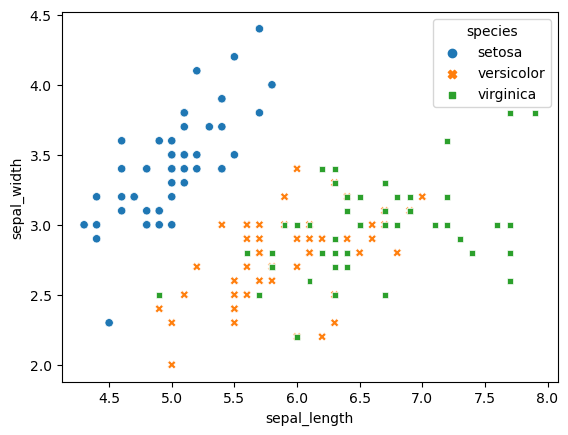

In [9]:
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species", style="species")

## Seaborn colour palettes

- such as: bright, deep, dark, pastel, Spectral

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

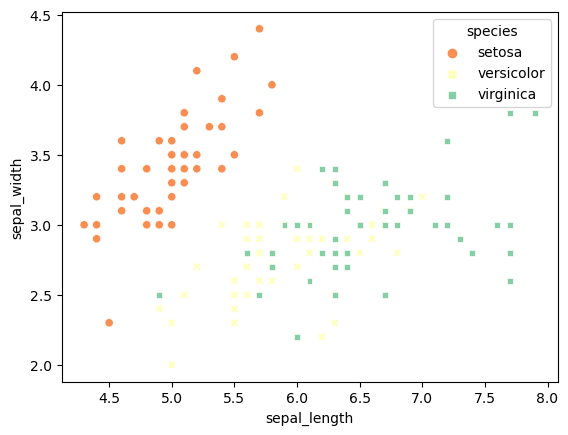

In [18]:
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species", style="species", palette="Spectral")

## Seaborn `pairplot`

- **Pairplots** are highly useful for studying variables over many dimensions or features. 

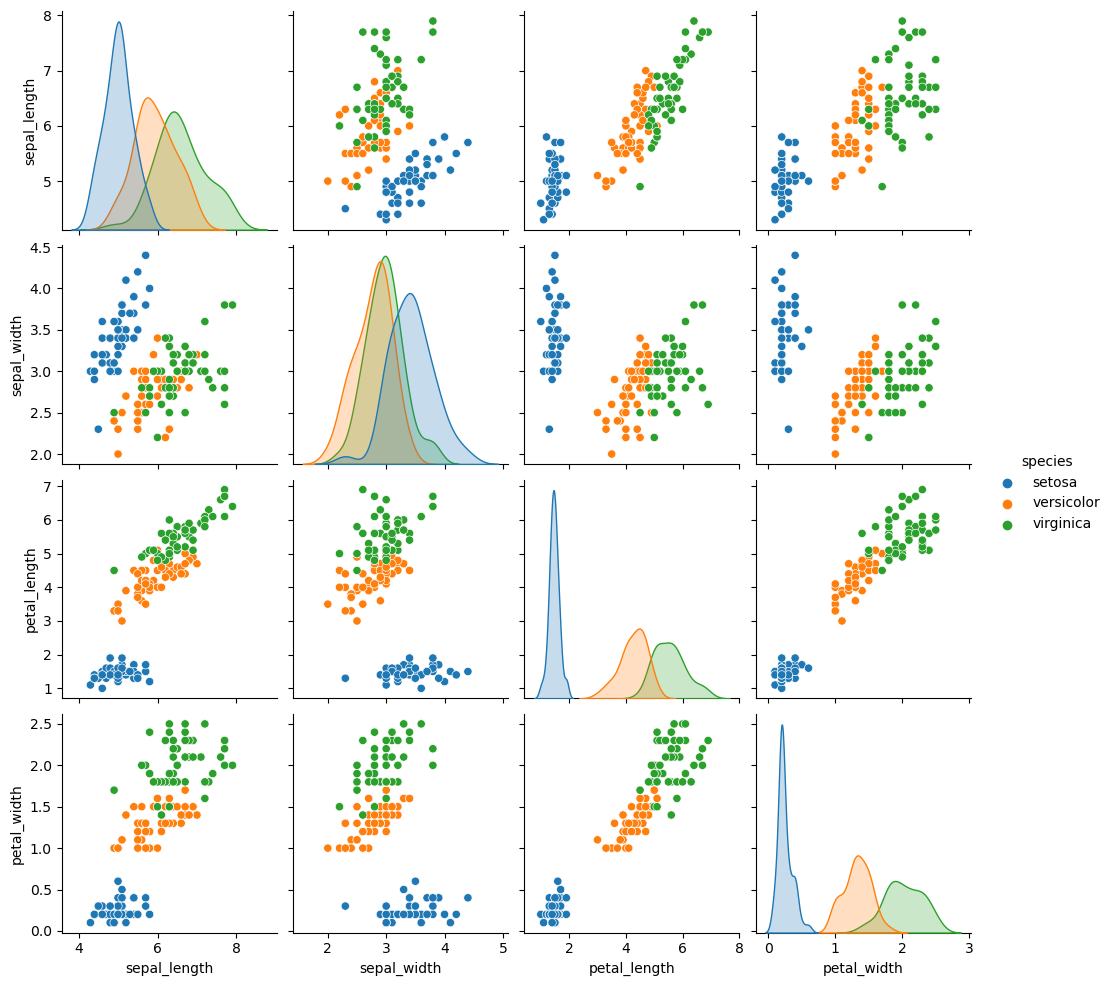

In [19]:
sns.pairplot(data=iris, hue="species")

## Advanced overlaying graph

- some **data handling** must be done to prepare the data for Seaborn for this purpose

In [25]:
iris["sepal"] = "sepal"
iris["petal"] = "petal"
iris1 = pd.DataFrame(data=iris[["sepal_length", "sepal_width", "species", "sepal"]])
iris1.columns = ["length", "width", "species", "measured"]
iris2 = pd.DataFrame(data=iris[["petal_length", "petal_width", "species", "petal"]])
iris2.columns = ["length", "width", "species", "measured"]
iris3 = pd.concat([iris1, iris2])
iris3

,length,width,species,measured
0,5.1,3.5,setosa,sepal
1,4.9,3.0,setosa,sepal
2,4.7,3.2,setosa,sepal
3,4.6,3.1,setosa,sepal
4,5.0,3.6,setosa,sepal
...,...,...,...,...
145,5.2,2.3,virginica,petal
146,5.0,1.9,virginica,petal
147,5.2,2.0,virginica,petal
148,5.4,2.3,virginica,petal


<Axes: xlabel='length', ylabel='width'>

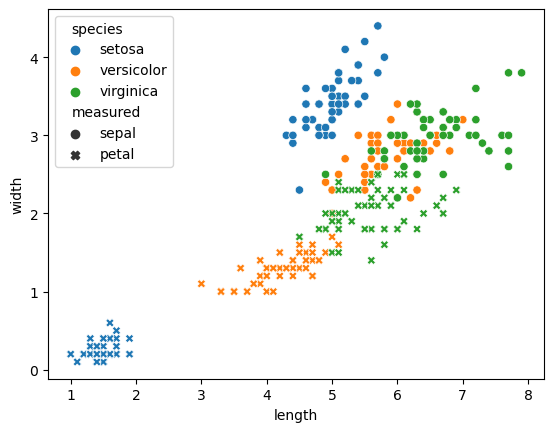

In [27]:
sns.scatterplot(data=iris3, x="length", y="width", hue="species", style="measured")